# Telco Customer Churn Analysis

## Project Overview

This project analyses customer churn in a telecommunications dataset using Python-based exploratory data analysis (EDA).

The analysis investigates whether customer characteristics, service subscriptions, contract types, payment methods and account-related factors are associated with customer churn.

### Research Question

**Which customer characteristics, service subscriptions, and account-related factors appear most strongly associated with churn in the Telco Customer Churn dataset?**

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Dataset Overview

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Description

The dataset contains customer-level information covering demographics, 
services, account details and churn status.

The main groups of variables include:

- **Customer characteristics:** gender, senior citizen status, partner and dependents
- **Tenure:** length of time with the company
- **Services:** phone, internet, security, backup, device protection and technical support
- **Account information:** contract type, billing method and payment method
- **Charges:** monthly and total charges
- **Target variable:** Churn

##Data Overview

In [ ]:
print('DataFrame Info\n')
df.info()


DataFrame Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

### Initial Observations

The dataset contains 7,043 customer records and 21 variables.

Most categorical variables are stored as objects, while `tenure` and 
`SeniorCitizen` are integers and `MonthlyCharges` is stored as a float.

`TotalCharges` is initially stored as an object rather than a numeric 
variable and therefore requires further preparation before numerical analysis.

In [ ]:
print('Missing values\n')
print(df.isnull().sum())

Missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print('Original DataFrame shape:', df.shape)
##df.dropna(inplace=True)
print('DataFrame shape after dropping missing values:', df.shape)
print(df.isnull().sum())
print('\nUpdated Information:')
df.info()

Original DataFrame shape: (7043, 21)
DataFrame shape after dropping missing values: (7043, 21)
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Updated Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents    

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Data Type Preparation

Although the initial missing-value check reports no null values, 
`TotalCharges` is stored as a text variable. Converting it to a numeric 
format allows non-numeric or blank entries to be identified and handled 
before further analysis.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('New data type of TotalCharges:', df['TotalCharges'].dtype)
print('Missing values in TotalCharges after conversion:', df['TotalCharges'].isna().sum())

New data type of TotalCharges: float64
Missing values in TotalCharges after conversion: 11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Preparation

### Encoding the Churn Variable

The `Churn` variable was converted from categorical values (`Yes`/`No`) 
to binary values (`1`/`0`) to support numerical analysis.

Class counts for churn


,count
Churn,
0,5174
1,1869


Class percentages for Churn


,proportion
Churn,
0,73.463013
1,26.536987


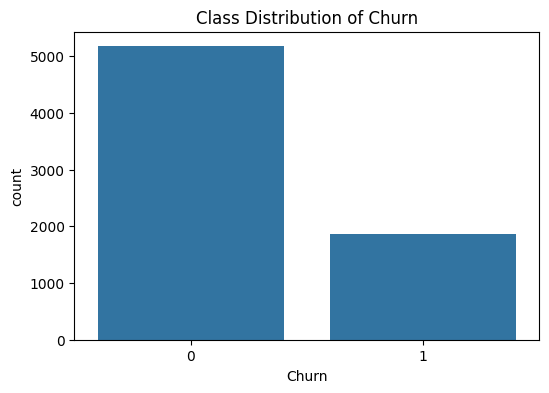

In [ ]:
#Convert Churn to numeric
df['Churn'] = df['Churn'].map({'No':0, 'Yes': 1})
print('Class counts for churn')
display(df['Churn'].value_counts())

print('Class percentages for Churn')
display(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Class Distribution of Churn')
plt.show()

### Churn Distribution

The dataset contains 7,043 customers. Approximately 26.5% of customers 
have churned, while 73.5% have remained with the company.

This indicates that the dataset is imbalanced toward non-churned customers, 
which should be considered when interpreting the analysis.

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#Fill missing TotalCharges values with the medean
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
 # Creates readable churn labels for charts
df["Churn_Label"] = df["Churn"].map({0: "Not Churned", 1: "Churned"})
 # Displays the original churn value and the new label
df[["Churn", "Churn_Label"]].head()

,Churn,Churn_Label
0,0,Not Churned
1,0,Not Churned
2,1,Churned
3,0,Not Churned
4,1,Churned


In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
duplicated_count = df.duplicated().sum()
print('Number of duplicated rows:', duplicated_count)

Number of duplicated rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Categorical and Numerical columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical Columns')
print(categorical_columns)

print('Numerical Columns')
print(numerical_columns)

Categorical Columns
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn_Label']
Numerical Columns
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


##Data summary

In [ ]:
print('Summary statistics for numerical columns')
df.describe()

Summary statistics for numerical columns


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [ ]:
print('Summary statistics for categorical columns')
display(df.describe(include='object'))

Summary statistics for categorical columns


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn_Label
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Not Churned
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


##Data Visualisation

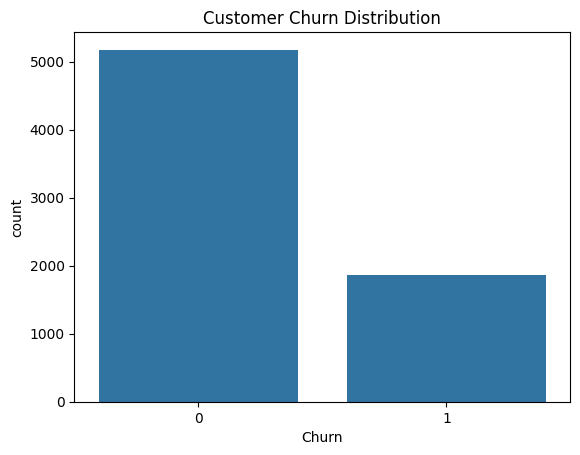

In [ ]:
#Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

####Customer Characteristics Visualisation

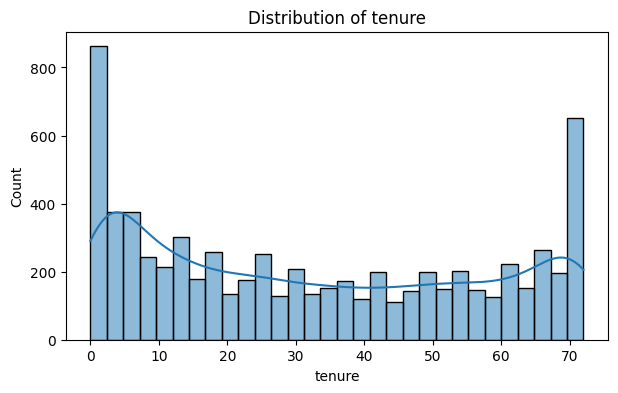

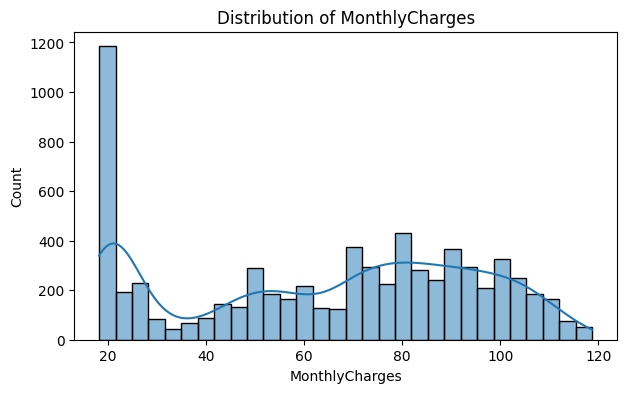

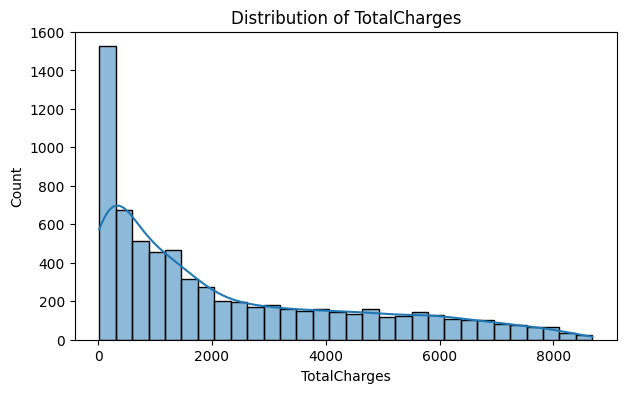

In [ ]:
# Histograms for numeric columns
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

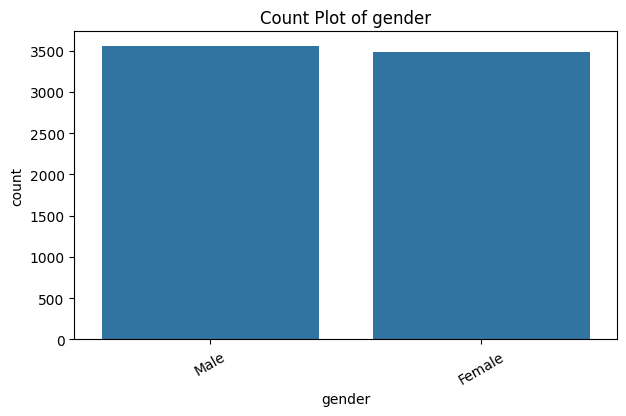

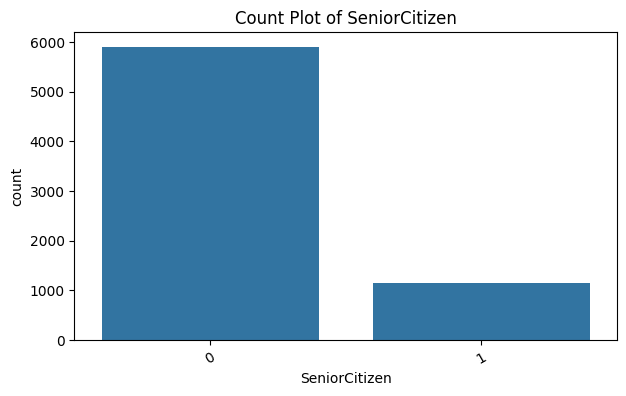

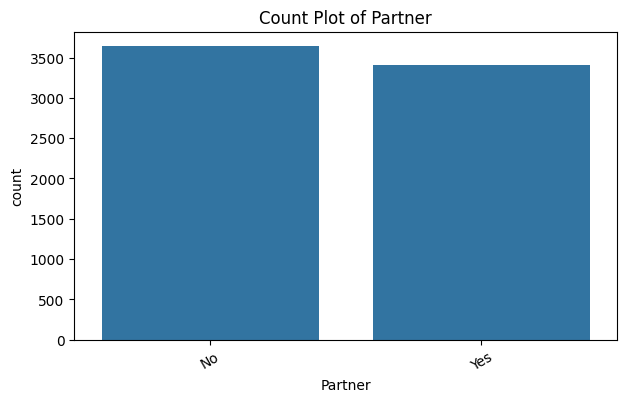

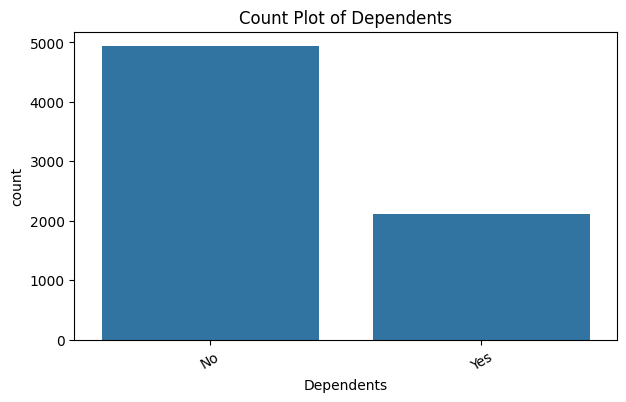

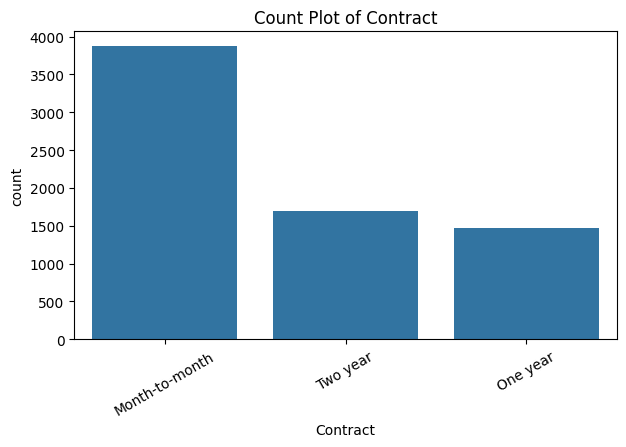

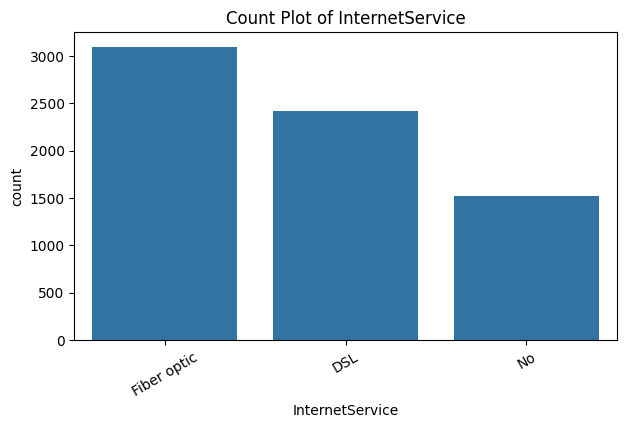

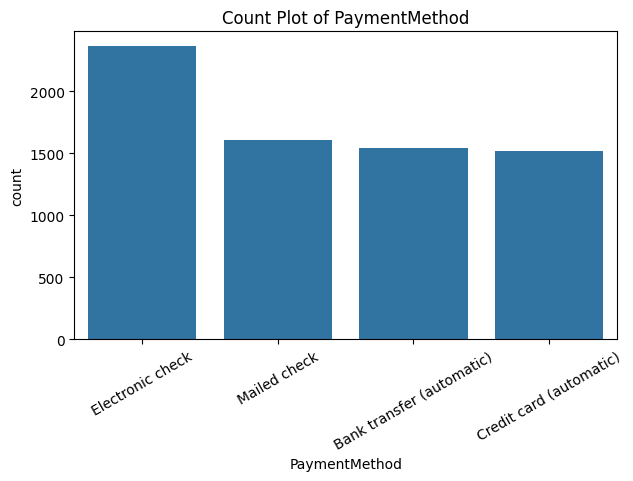

In [ ]:
# Count plots for important categorical columns
important_categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'InternetService', 'PaymentMethod']

for col in important_categorical:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=30)
    plt.show()

####Customer Characteristics Visualisations

Churn percentage by gender


Churn,0,1
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


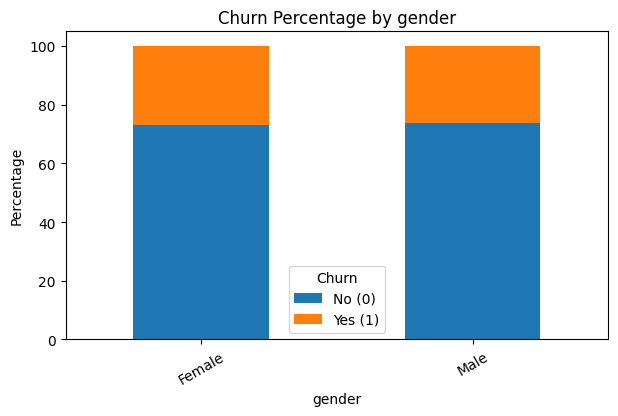

Churn percentage by SeniorCitizen


Churn,0,1
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


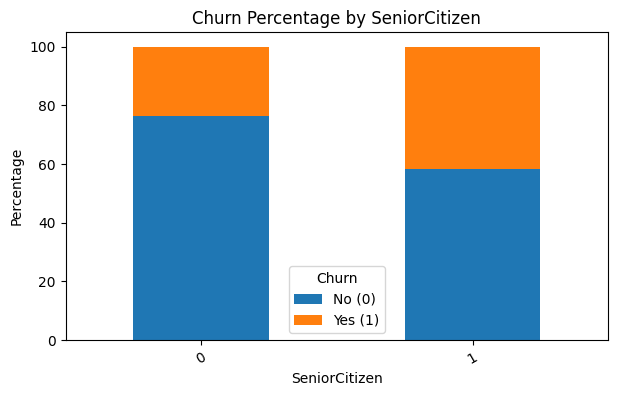

Churn percentage by Partner


Churn,0,1
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


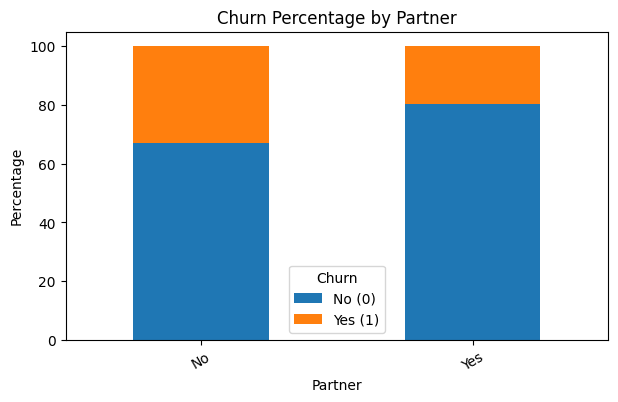

Churn percentage by Dependents


Churn,0,1
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


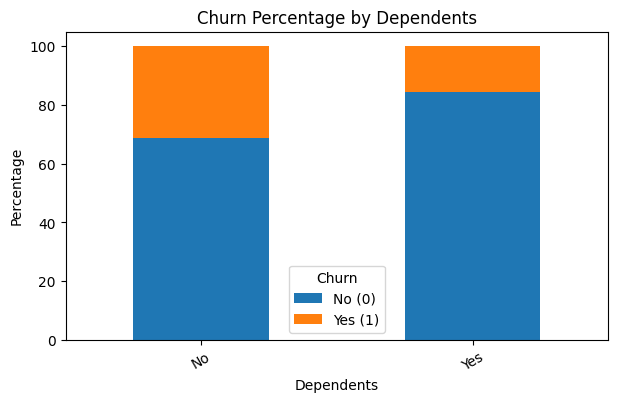

Churn percentage by tenure


Churn,0,1
tenure,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
...,...,...
68,91.000000,9.000000
69,91.578947,8.421053
70,90.756303,9.243697


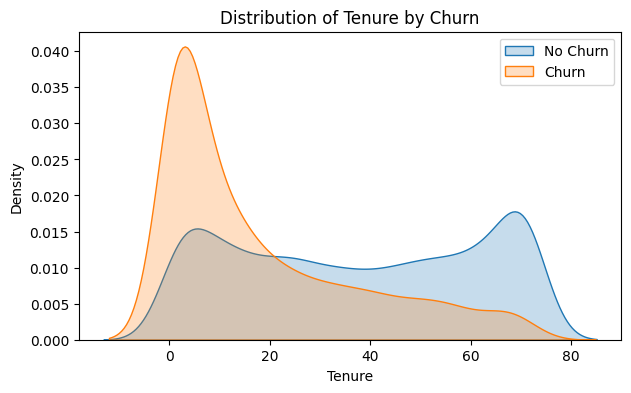

In [ ]:
#Gender, SeniorCitizen, Partner, Dependencies, Tenure

for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    churn_table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print('Churn percentage by', col)
    display(churn_table)

    churn_table.plot(kind='bar', stacked=True, figsize=(7,4))
    plt.title(f'Churn Percentage by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=30)
    plt.legend(title='Churn', labels=['No (0)', 'Yes (1)'])
    plt.show()

#Tenure
for col in ['tenure']:
    churn_table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print('Churn percentage by', col)
    display(churn_table)

plt.figure(figsize=(7,4))
sns.kdeplot(df[df['Churn'] == 0]['tenure'], label='No Churn', fill=True)
sns.kdeplot(df[df['Churn'] == 1]['tenure'], label='Churn', fill=True)

plt.title('Distribution of Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Density')
plt.legend()
plt.show()


####Sevice Subscriptions Visualisations

Churn percentage by InternetService


Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


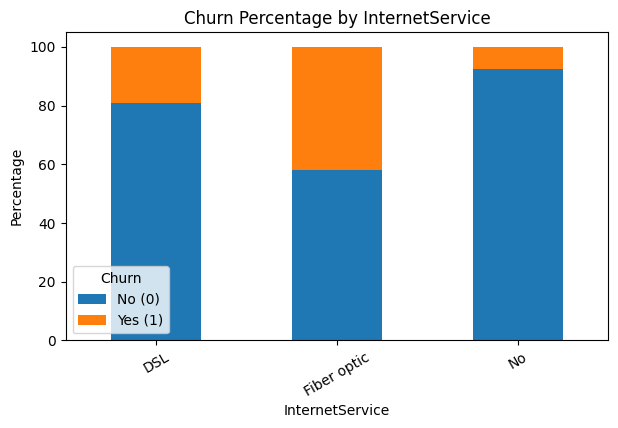

Churn percentage by OnlineSecurity


Churn,0,1
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


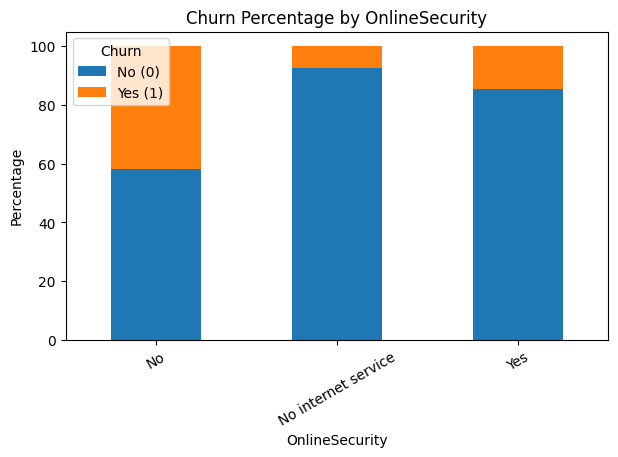

Churn percentage by StreamingTV


Churn,0,1
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


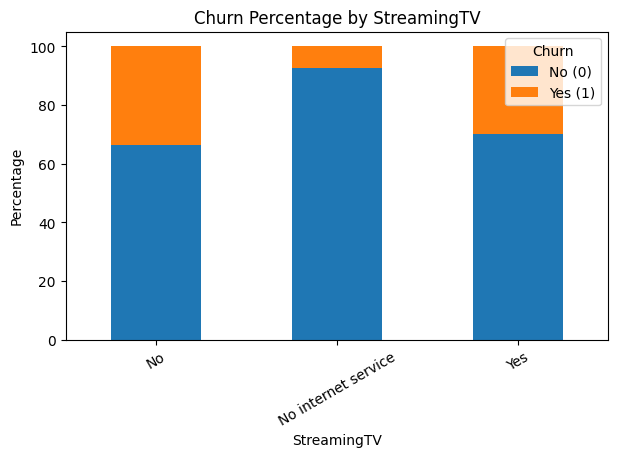

Churn percentage by TechSupport


Churn,0,1
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


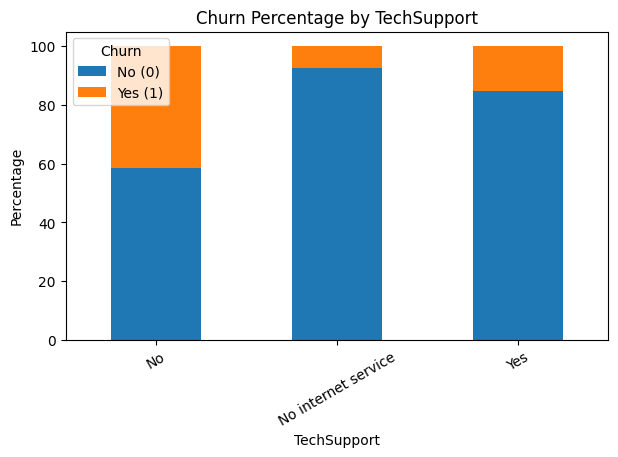

In [ ]:
#InternetService, OnlineSecuriy, StreamingTV
for col in ['InternetService', 'OnlineSecurity', 'StreamingTV', 'TechSupport']:
    churn_table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print('Churn percentage by', col)
    display(churn_table)

    churn_table.plot(kind='bar', stacked=True, figsize=(7,4))
    plt.title(f'Churn Percentage by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=30)
    plt.legend(title='Churn', labels=['No (0)', 'Yes (1)'])
    plt.show()

####Account Related Factors Visualisation

Churn percentage by Contract


Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


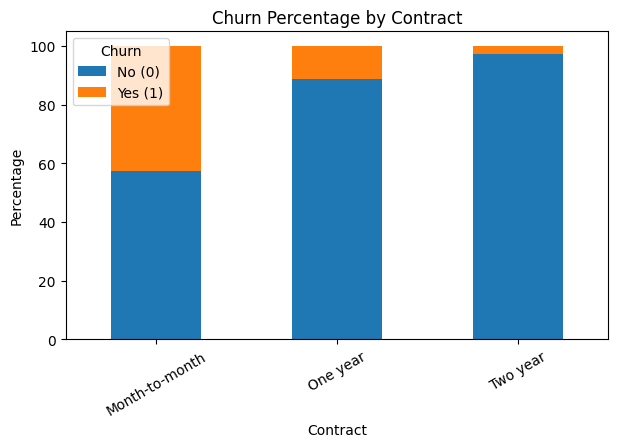

Churn percentage by PaymentMethod


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


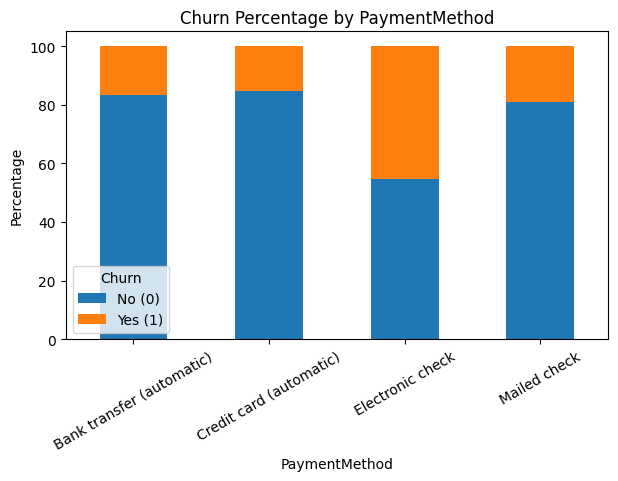

Churn percentage by PaperlessBilling


Churn,0,1
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


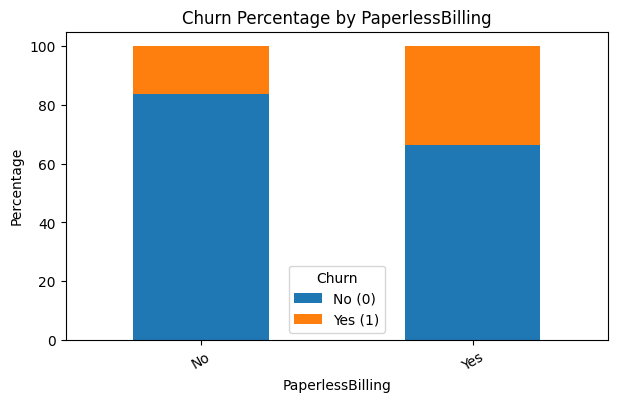

Churn percentage by MonthlyCharges


Churn,0,1
MonthlyCharges,,
18.25,100.0,0.0
18.40,100.0,0.0
18.55,100.0,0.0
18.70,100.0,0.0
18.75,100.0,0.0
...,...,...
118.20,100.0,0.0
118.35,0.0,100.0
118.60,100.0,0.0


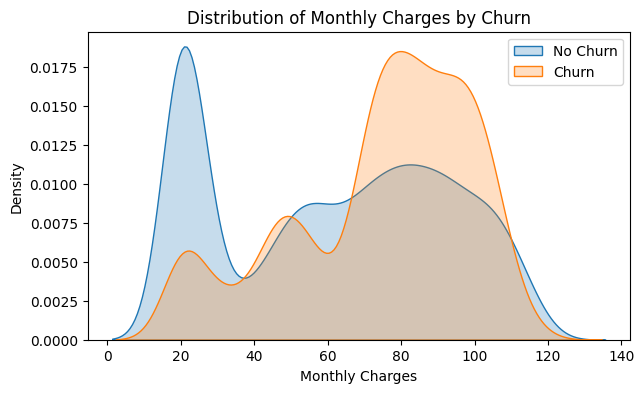

In [ ]:
#Contract, MonthlyCharges, PaymentMethod, PaperlessBilling
for col in ['Contract','PaymentMethod', 'PaperlessBilling']:
    churn_table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print('Churn percentage by', col)
    display(churn_table)

    churn_table.plot(kind='bar', stacked=True, figsize=(7,4))
    plt.title(f'Churn Percentage by {col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=30)
    plt.legend(title='Churn', labels=['No (0)', 'Yes (1)'])
    plt.show()

#MonthlyCharges
for col in ['MonthlyCharges']:
    churn_table = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print('Churn percentage by', col)
    display(churn_table)

plt.figure(figsize=(7,4))
sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], label='No Churn', fill=True)
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], label='Churn', fill=True)

plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.legend()
plt.show()

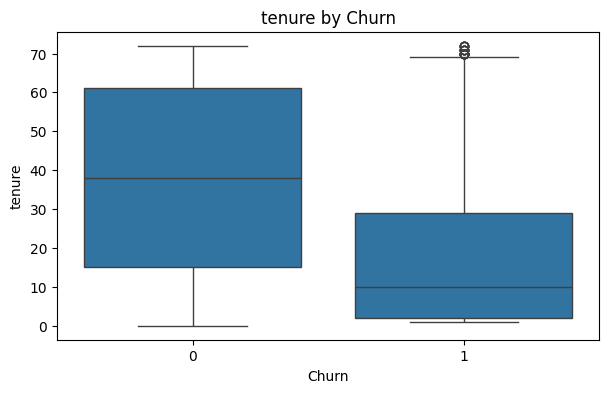

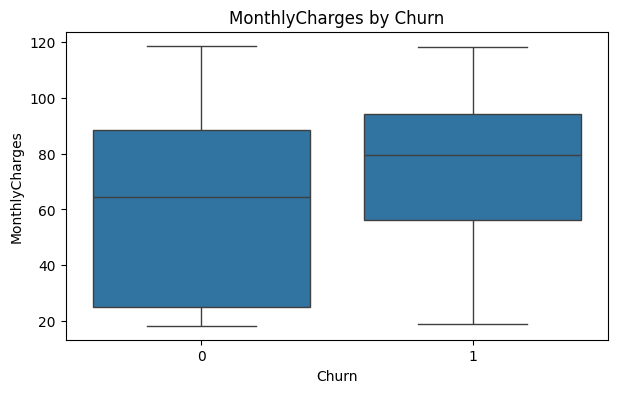

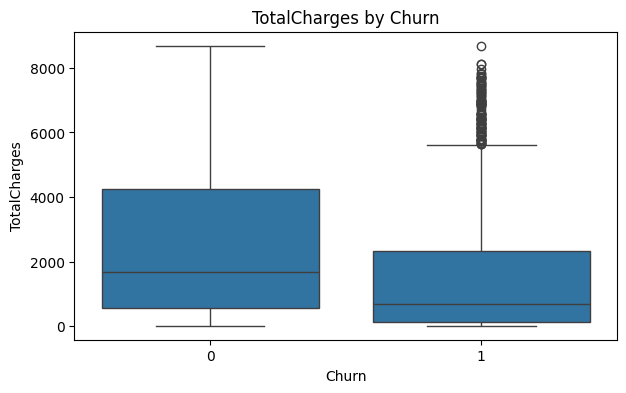

In [ ]:
#Boxplot for numerical columns
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} by Churn')
    plt.show()

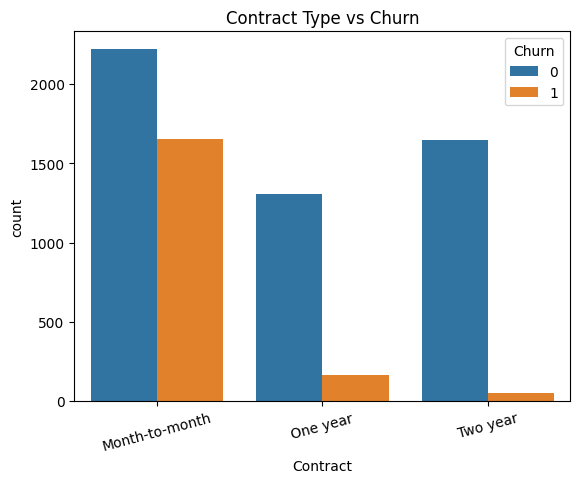

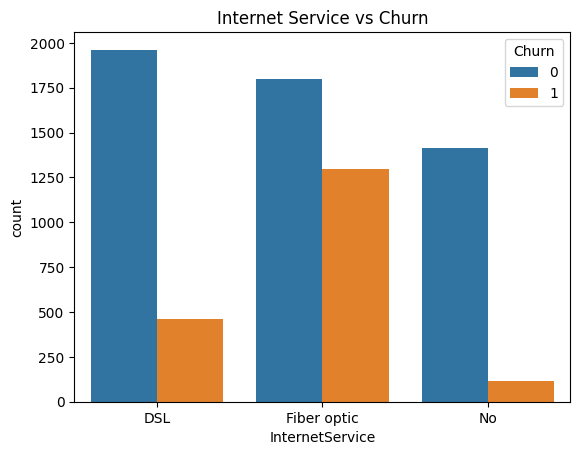

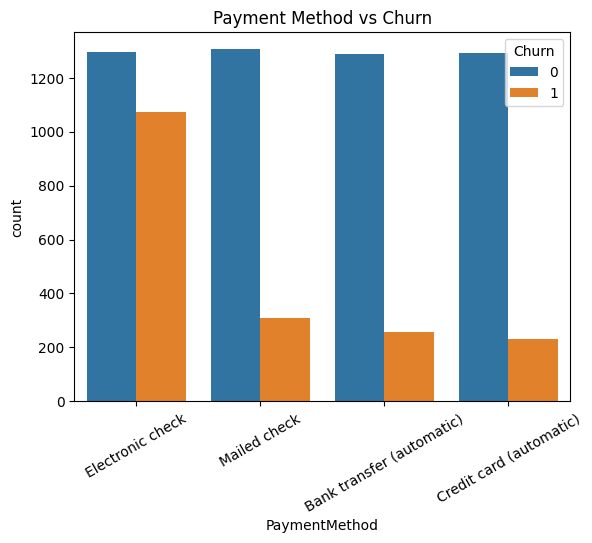

In [ ]:
#Analyze Categorical Variables

#Contract Type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

#Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

#Payment Method
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=30)
plt.show()

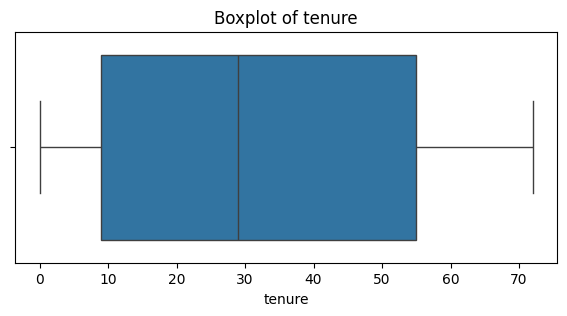

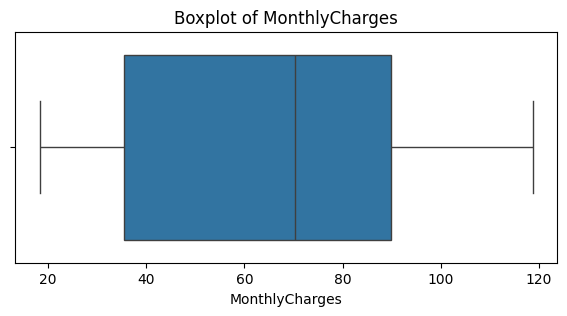

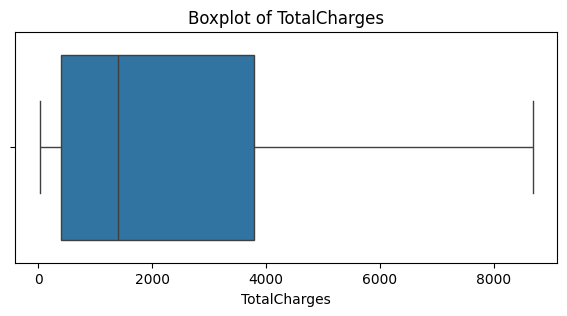

In [ ]:
#outlier for numerical columns
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
outlier_summary = []

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary.append([
        col,
        Q1,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        outlier_count,
        outlier_percentage
    ])

outlier_table = pd.DataFrame(outlier_summary, columns=[
    'Column', 'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier Percentage'
])

display(outlier_table)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,tenure,9.000,55.00,46.000,-60.0000,124.0000,0,0.0
1,MonthlyCharges,35.500,89.85,54.350,-46.0250,171.3750,0,0.0
2,TotalCharges,402.225,3786.60,3384.375,-4674.3375,8863.1625,0,0.0


## 11. Correlation matrix and heatmap

Correlation measures how strongly two numeric variables move together.
- Values close to **+1**: strong positive relationship
- Values close to **-1**: strong negative relationship
- Values close to **0**: weak linear relationship


Categorical input variables to be one-hot encoded:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dataset shape after encoding:
(7043, 31)

First 5 rows of the encoded dataset:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2  

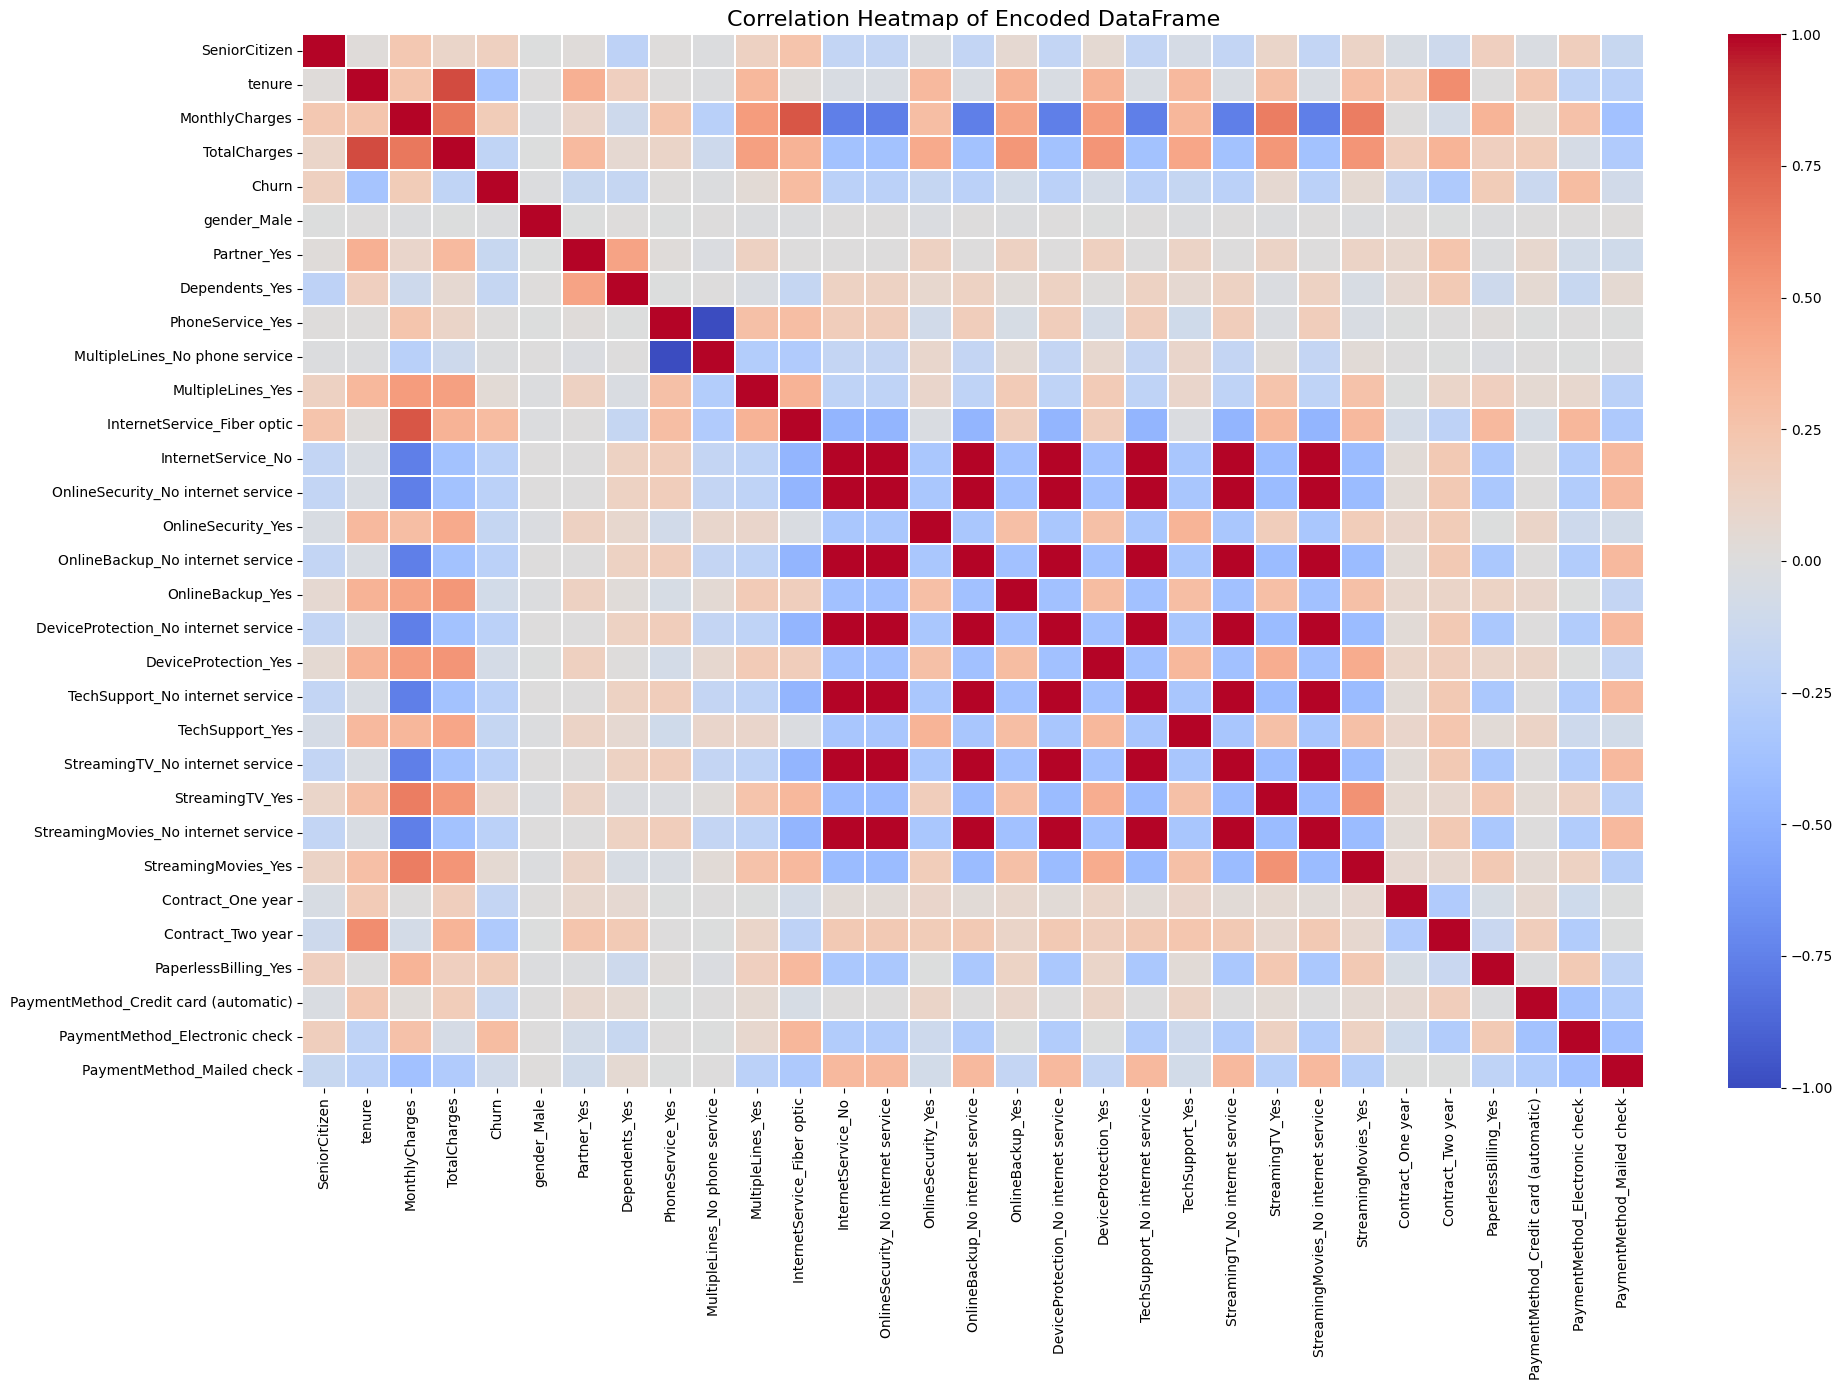

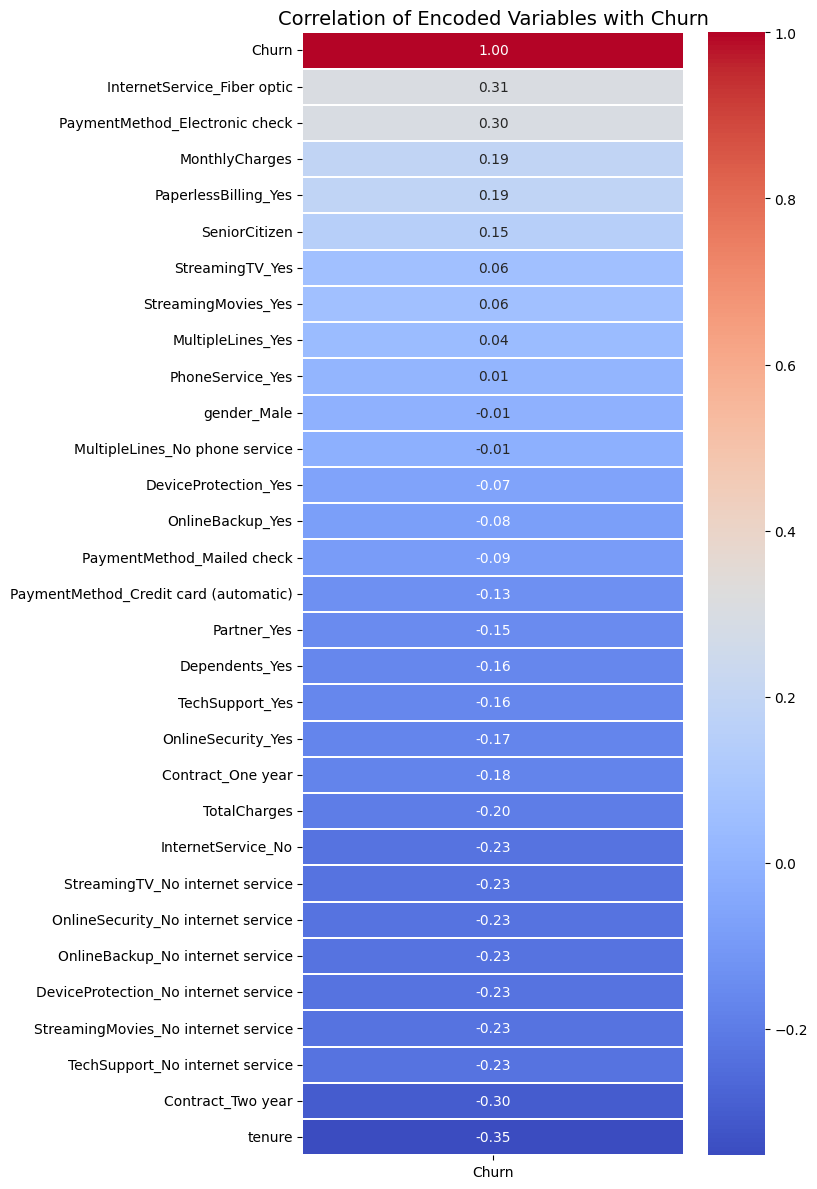

In [ ]:
# =========================
# 1. Import required libraries
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2. Make a copy of the dataset
# =========================
df_encoded = df.copy()
df_encoded = df.copy()
# Drop tracking IDs and text descriptive columns before encoding
columns_to_drop = ['customerID', 'Churn_Label']
df_encoded = df_encoded.drop(columns=[col for col in columns_to_drop if col in df_encoded.columns])
# Remove Churn_numeric if it exists
if 'Churn_numeric' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['Churn_numeric'])

# =========================
# 3. Convert TotalCharges to numeric if necessary
# =========================
# In this dataset, TotalCharges may sometimes be stored as text
# errors='coerce' converts invalid values to NaN
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

# Fill missing values in TotalCharges with the median
df_encoded['TotalCharges'] = df_encoded['TotalCharges'].fillna(df_encoded['TotalCharges'].median())


# =========================
# 4. Drop customerID if it exists
# =========================
# customerID is just an identifier and should not be used as a feature
if 'customerID' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['customerID'])

# =========================
# 5. Identify categorical input variables
# =========================
categorical_columns = df_encoded.select_dtypes(include=['object']).columns

print("\nCategorical input variables to be one-hot encoded:")
print(list(categorical_columns))

# =========================
# 6. Apply one-hot encoding to categorical input variables
# =========================
# drop_first=True avoids redundant columns and reduces multicollinearity
df_encoded = pd.get_dummies(df_encoded, columns=categorical_columns, drop_first=True)

# Convert boolean dummy columns to integers for cleaner correlation output
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("\nDataset shape after encoding:")
print(df_encoded.shape)

print("\nFirst 5 rows of the encoded dataset:")
print(df_encoded.head())
# =========================
# 7. Display all columns in the encoded dataframe
# =========================
print("\nEncoded dataframe columns:")
print(list(df_encoded.columns))

# =========================
# 8. Compute correlation matrix
# =========================
corr_matrix = df_encoded.corr()

# =========================
# 9. Display correlation table with Churn
# =========================
print("\nCorrelation of all encoded variables with Churn:")
corr_with_churn = corr_matrix['Churn'].sort_values(ascending=False)
print(corr_with_churn)
print("\nTop Positive Correlations with Churn:")
print(corr_with_churn.sort_values(ascending=False).head(10))

print("\nTop Negative Correlations with Churn:")
print(corr_with_churn.sort_values().head(10))
# =========================
# 10. Display the full correlation table
# =========================
print("\nFull Correlation Table:")
print(corr_matrix)

# =========================
# 11. Plot full correlation heatmap
# =========================
plt.figure(figsize=(20, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap of Encoded DataFrame", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# =========================
# 12. Plot a smaller heatmap focusing on correlation with Churn
# =========================
# This is easier to read when there are many encoded columns
corr_with_churn_df = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(8, 12))

sns.heatmap(
    corr_with_churn_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.3
)

plt.title("Correlation of Encoded Variables with Churn", fontsize=14)
plt.tight_layout()
plt.show()


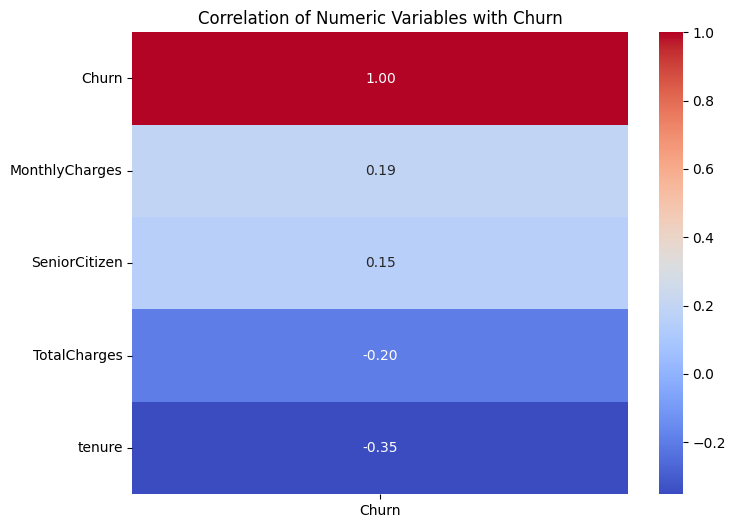

In [ ]:
# This heatmap focuses only on numeric variables in the dataset.
# It helps identify basic linear relationships between churn and numerical customer features.

# 1. Calculate the correlation matrix first
# Note: .corr() only works on numeric columns, so we select those specifically
correlation_matrix = df.select_dtypes(include=['number']).corr()

# 2. Now your original code will work
churn_correlation = correlation_matrix[["Churn"]].sort_values(by="Churn", ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(churn_correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Numeric Variables with Churn")
plt.show()

In [ ]:
# Saving the cleaned, processed dataframe to a CSV file
df.to_csv('telco_churn_cleaned.csv', index=False)


from google.colab import files
files.download('telco_churn_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Most Important Findings

##Strong churn indicators:
Month-to-month contracts

High monthly charges

Short tenure

Fiber optic internet users

Electronic check payment users

##Lower churn indicators:
Long-term contracts

Longer tenure

Lower monthly charges